# Introduction to Natural Language Processing: Assignment 3

In this exercise we'll practice training RNN & LSTM models as well as fine-tuning LLMs to predict one or more labels for a given text using Hugging Face and PyTorch.

- You can use any Python package you need.
- Please comment your code
- Submissions are due Tuesdays at 23:59 **only** on eCampus: **Assignmnets >> Student Submissions >> Assignment 3 (Deadline: 09.12.2025, at 23:59)**

- Name the file aproppriately: "Assignment_3_\<Your_Name\>.ipynb" and submit only the Jupyter Notebook file.

### Task 1 (15 points)

In this task you will implement text generation in torch with a multi-layer RNN and multi-layer LSTM.

a) Implement the missing methods of the dataset class to
1. load the dataset from the file `reddit-cleanjokes.csv` and split it into words [**(dataset link)**](https://raw.githubusercontent.com/amoudgl/short-jokes-dataset/master/data/reddit-cleanjokes.csv)
2. get a list of the unique words
3. implement the `__getitem__` method to iterate through the dataset. Hint: use `torch.tensor` to turn a list into a tensor.

Then instantiate the dataset with `sequence_length=4`

In [38]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [39]:
import torch

from torch import Tensor
from typing import List
# hint: use these methods
from pandas import read_csv
from collections import Counter

import string

class Dataset(torch.utils.data.Dataset):
    def __init__(
        self,
        sequence_length,
    ):
        self.sequence_length = sequence_length
        self.words = self.load_words()
        self.uniq_words = self.get_uniq_words()

        self.index_to_word = {index: word for index, word in enumerate(self.uniq_words)}
        self.word_to_index = {word: index for index, word in enumerate(self.uniq_words)}

        self.words_indexes = [self.word_to_index[w] for w in self.words]

    def load_words(self) -> List[str]:
        """Returns a list of all words in the dataset.
        Make sure to strip punctuation and lowercase the words"""
        # YOUR CODE HERE
        # load the data
        data = read_csv('https://raw.githubusercontent.com/amoudgl/short-jokes-dataset/master/data/reddit-cleanjokes.csv')
        # put everything in a long string and replace punctuation for spaces
        text = ' '.join(data['Joke'].tolist())
        text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
        # lowercase the data and split it into a list of words
        words = [word.strip() for word in text.lower().split() if word.strip()]
        return words

    def get_uniq_words(self) -> List[str]:
        """Returns a list, containing each unique word in the dataset once"""
        # YOUR CODE HERE
        # gets a unique list of all words after counting them in a dictionary
        word_counts = Counter(self.words)
        return list(word_counts.keys())

    def __len__(self) -> int:
        """Returns the number of `self.sequence_length` length word spans in the dataset"""
        return len(self.words_indexes) - self.sequence_length

    def __getitem__(self, index) -> (Tensor, Tensor):
        """Returns a tuple of two torch.Tensors:
        an input sequence for the RNN/LSTM model and a target sequence.
        The tensors should be 1D and have length equal to self.sequence_length.
        Remember that the target should be shifted with respect to the input."""
        # YOUR CODE HERE
        # defines the indexes for the input and target sequences according to the length of the sequence
        input_seq_index = self.words_indexes[index : index + self.sequence_length]
        target_seq_index = self.words_indexes[index + 1 : index + self.sequence_length + 1]

        # convert to tensors
        input_tensor = torch.tensor(input_seq_index, dtype=torch.long)
        target_tensor = torch.tensor(target_seq_index, dtype=torch.long)
        
        return input_tensor, target_tensor


In [40]:
dataset = Dataset(4)
dataset.load_words()

['what',
 'did',
 'the',
 'bartender',
 'say',
 'to',
 'the',
 'jumper',
 'cables',
 'you',
 'better',
 'not',
 'try',
 'to',
 'start',
 'anything',
 'don',
 't',
 'you',
 'hate',
 'jokes',
 'about',
 'german',
 'sausage',
 'they',
 're',
 'the',
 'wurst',
 'two',
 'artists',
 'had',
 'an',
 'art',
 'contest',
 'it',
 'ended',
 'in',
 'a',
 'draw',
 'why',
 'did',
 'the',
 'chicken',
 'cross',
 'the',
 'playground',
 'to',
 'get',
 'to',
 'the',
 'other',
 'slide',
 'what',
 'gun',
 'do',
 'you',
 'use',
 'to',
 'hunt',
 'a',
 'moose',
 'a',
 'moosecut',
 'if',
 'life',
 'gives',
 'you',
 'melons',
 'you',
 'might',
 'have',
 'dyslexia',
 'broken',
 'pencils',
 'are',
 'pointless',
 'what',
 'did',
 'one',
 'snowman',
 'say',
 'to',
 'the',
 'other',
 'snowman',
 'do',
 'you',
 'smell',
 'carrots',
 'how',
 'many',
 'hipsters',
 'does',
 'it',
 'take',
 'to',
 'change',
 'a',
 'lightbulb',
 'it',
 's',
 'a',
 'really',
 'obscure',
 'number',
 'you',
 've',
 'probably',
 'never',
 'hear

b) Now, complete the implementation of the RNN model.

You'll need to use all the model components defined in `__init__`: [Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html), [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html), and the [Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) output layer. These are all subclasses of [`torch.nn.Module`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html).

Torch Modules are objects that hold the layer's weights and biases (called parameters, accessed by `model.parameters()`) and keep track of a bunch of metadata, like what device the weights are on or what precision they're stored at. Each Module can have parts that are themselves Modules. The easiest way to combine Modules is with [`torch.nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html).

Every Module must have a `forward` method. This defines what the Module does with its input and returns as output. You can access `forward` simply by calling the Module, for example `output = self.rnn(input)`. This is the preferred way to write it.

Hint: unlike the one we saw in the tutorial, this RNN has multiple layers. Think about what this means for the shape of the hidden state. You might not want to use Sequential as RNN has multiple inputs and outputs.

In [47]:
import torch
from torch import nn

class RNNModel(nn.Module):
    def __init__(self, dataset):
        super(RNNModel, self).__init__()
        self.hidden_size = 128
        self.embedding_dim = 128
        self.num_layers = 3

        n_vocab = len(dataset.uniq_words)
        self.embedding = nn.Embedding(
            num_embeddings=n_vocab,
            embedding_dim=self.embedding_dim,
        )
        self.rnn = nn.RNN(
            input_size=self.hidden_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            dropout=0.2,
        )
        self.fc = nn.Linear(self.hidden_size, n_vocab)

    def init_state(self, sequence_length: int) -> Tensor:
        """Returns the initial state hidden state (all zeros), with the correct shape."""
        # YOUR CODE HERE
        # building it according to (num_layers x batch_size x hidden_size)
        return torch.zeros(self.num_layers, sequence_length, self.hidden_size).to(device)

    def forward(self, inputs: Tensor, prev_hidden_state: Tensor) -> (Tensor, Tensor):
        """Compute the logits and next_hidden_state."""
        # YOUR CODE HERE
        # embed the inputs
        embedded_inputs = self.embedding(inputs)
        # process the RNN
        output, next_hidden_state = self.rnn(embedded_inputs, prev_hidden_state)
        # now we reshape the RNN output to pass it through the fully connected layer and get the logits
        output = output.reshape(-1, self.hidden_size)
        logits = self.fc(output)
        return logits, next_hidden_state

In [49]:
model = RNNModel(dataset)
model = model.to(device)

c) Write a function that counts the total number of parameters and total number of trainable parameters of a model.

Refer to the [torch documentation](https://pytorch.org/docs/stable/index.html).

In [50]:
def count_params(model: nn.Module) -> (int, int):
    # YOUR CODE HERE
    n_params = 0
    n_trainable_params = 0

    for param in model.parameters():
        # get the number of parameters in the tensor
        num_elements = param.numel()
        n_params += num_elements
        # check if the parameters are trainable
        if param.requires_grad:
            n_trainable_params += num_elements
            
    return n_params, n_trainable_params

d) Complete the training loop and train the model for 10 epochs. Store the training loss in a list. You will probably want to have an inner loop that loops over batches.

Hint: refer to the documentation of the `DataLoader`, `CrossEntropyLoss` and `Optimizer` classes. You might also need to use the `detach()` and `item()` methods to work with the loss tensor.

In [53]:
import torch
import numpy as np
from torch import nn, optim
from torch.utils.data import DataLoader

def train_rnn(dataset, model, sequence_length, batch_size, max_epochs) -> List[float]:
    model.train()

    dataloader = DataLoader(dataset, batch_size=batch_size)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_list = []

    for epoch in range(max_epochs):
        # YOUR CODE HERE
        hidden_state = model.init_state(sequence_length) 
        
        epoch_loss = 0.0
        
        # Inner loop over batches from the DataLoader
        for inputs, targets in dataloader:

            inputs = inputs.to(device)
            targets = targets.to(device)
            
            # --- 3. Detach Hidden State and Zero Gradients ---
            # Detach the hidden state from its history to prevent backpropagating 
            # through the entire dataset history (Truncated Backpropagation Through Time)
            # .detach() is also necessary here for RNNs to avoid memory leaks.
            hidden_state = hidden_state.detach()
            
            optimizer.zero_grad() # Clear previous gradients
            
            # --- 4. Forward Pass ---
            # Pass inputs and the (detached) hidden state to the model
            # logits shape: (batch_size * sequence_length, n_vocab)
            # targets shape: (batch_size, sequence_length)
            logits, hidden_state = model(inputs, hidden_state)
            
            # --- 5. Compute Loss ---
            # CrossEntropyLoss expects (N, C) logits and (N) targets.
            # We must flatten the targets to match the flattened logits.
            # Flattened target shape: (batch_size * sequence_length)
            loss = criterion(logits, targets.flatten())
            
            # --- 6. Backward Pass and Optimization ---
            loss.backward() # Compute gradients
            
            # Optional: Gradient clipping to prevent exploding gradients
            # nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0) 
            
            optimizer.step() # Update model weights
            
            # Accumulate loss for the current epoch
            # .item() extracts the scalar value from the 0D tensor
            epoch_loss += loss.item()

        # 7. Log and Store Epoch Loss
        avg_epoch_loss = epoch_loss / len(dataloader)
        loss_list.append(avg_epoch_loss)
        print(f"Epoch {epoch+1}/{max_epochs}, Loss: {avg_epoch_loss:.4f}")

    return loss_list

In [70]:
train_loss_rnn = train_rnn(dataset, model, 4, 256, 300)

Epoch 1/300, Loss: 0.4441
Epoch 2/300, Loss: 0.4086
Epoch 3/300, Loss: 0.4014
Epoch 4/300, Loss: 0.3966
Epoch 5/300, Loss: 0.3881
Epoch 6/300, Loss: 0.3870
Epoch 7/300, Loss: 0.3789
Epoch 8/300, Loss: 0.3735
Epoch 9/300, Loss: 0.3677
Epoch 10/300, Loss: 0.3654
Epoch 11/300, Loss: 0.3606
Epoch 12/300, Loss: 0.3563
Epoch 13/300, Loss: 0.3476
Epoch 14/300, Loss: 0.3469
Epoch 15/300, Loss: 0.3423
Epoch 16/300, Loss: 0.3299
Epoch 17/300, Loss: 0.3258
Epoch 18/300, Loss: 0.3262
Epoch 19/300, Loss: 0.3214
Epoch 20/300, Loss: 0.3177
Epoch 21/300, Loss: 0.3148
Epoch 22/300, Loss: 0.3053
Epoch 23/300, Loss: 0.2980
Epoch 24/300, Loss: 0.2962
Epoch 25/300, Loss: 0.2952
Epoch 26/300, Loss: 0.2885
Epoch 27/300, Loss: 0.2877
Epoch 28/300, Loss: 0.2843
Epoch 29/300, Loss: 0.2830
Epoch 30/300, Loss: 0.2774
Epoch 31/300, Loss: 0.2767
Epoch 32/300, Loss: 0.2700
Epoch 33/300, Loss: 0.2635
Epoch 34/300, Loss: 0.2654
Epoch 35/300, Loss: 0.2626
Epoch 36/300, Loss: 0.2551
Epoch 37/300, Loss: 0.2539
Epoch 38/3

e) Complete the function to generate output from the model using 1. argmax (greedy) decoding 2. softmax decoding. Generate some sample outputs with each and discuss briefly.

Hint: torch already has a builtin function for getting the softmax of a tensor, which you may use.

In [75]:
def predict_rnn_argmax(dataset: Dataset, model: nn.Module, text: str, next_words=100) -> List[str]:
    model.eval()

    # YOUR CODE HERE
    text = text.lower().replace('.', ' ').replace(',', ' ').replace('!', ' ') 
    words = text.split() 
    
    try:
        current_input_indices = [dataset.word_to_index[w] for w in words]
    except KeyError as e:
        print(f"Warning: Word '{e.args[0]}' not in vocabulary. Skipping prediction.")
        return words
        
    batch_size = 1
    device = next(model.parameters()).device 
    
    # 2. Initialize hidden state with batch_size = 1
    hidden_state = model.init_state(batch_size).to(device) # Shape (3, 1, 128)
    
    # 3. Process the seed text ONE WORD AT A TIME to "warm up" the hidden state
    with torch.no_grad():
        
        # Pass the words one by one
        for index in current_input_indices:
            # Input shape: (batch_size=1, sequence_length=1)
            input_tensor = torch.tensor([[index]], dtype=torch.long).to(device)
            
            # The output logits are discarded, we only update the hidden state
            _, hidden_state = model(input_tensor, hidden_state) 
        
        # 4. Start generation from the last word processed
        current_word_index = current_input_indices[-1] # This is the index of the last word in the seed
        
        for _ in range(next_words):
            # Input for the next step is the single predicted word from the last step
            # Shape: (batch_size=1, sequence_length=1)
            input_tensor = torch.tensor([[current_word_index]], dtype=torch.long).to(device)
            
            # Forward pass to get logits for the *next* word
            logits, hidden_state = model(input_tensor, hidden_state)
            
            # ARGMAX (Greedy) DECODING
            current_word_index = torch.argmax(logits, dim=1).item()
            
            word = dataset.index_to_word[current_word_index]
            words.append(word)

    return words

def predict_rnn_softmax(dataset: Dataset, model: nn.Module, text: str, next_words=100) -> List[str]:
    model.eval()

    # YOUR CODE HERE
    text = text.lower().replace('.', ' ').replace(',', ' ').replace('!', ' ') 
    words = text.split() 
    
    try:
        current_input_indices = [dataset.word_to_index[w] for w in words]
    except KeyError as e:
        print(f"Warning: Word '{e.args[0]}' not in vocabulary. Skipping prediction.")
        return words
        
    batch_size = 1
    device = next(model.parameters()).device 
    
    # 2. Initialize hidden state with batch_size = 1
    # Shape: (num_layers, 1, hidden_size)
    hidden_state = model.init_state(batch_size).to(device)
    
    # 3. Process the seed text ONE WORD AT A TIME to "warm up" the hidden state
    with torch.no_grad():
        
        # Pass the words one by one
        for index in current_input_indices:
            # Input shape: (batch_size=1, sequence_length=1)
            input_tensor = torch.tensor([[index]], dtype=torch.long).to(device)
            
            # The output logits are discarded, we only update the hidden state
            _, hidden_state = model(input_tensor, hidden_state) 
        
        # 4. Start generation from the last word processed
        current_word_index = current_input_indices[-1]
        
        for _ in range(next_words):
            # Input for the next step is the single predicted word from the last step
            # Shape: (batch_size=1, sequence_length=1)
            input_tensor = torch.tensor([[current_word_index]], dtype=torch.long).to(device)
            
            # Forward pass to get logits for the *next* word
            logits, hidden_state = model(input_tensor, hidden_state)
            
            # --- SOFTMAX (Sampling) DECODING ---
            probabilities = torch.softmax(logits, dim=1)
            # Sample one index based on the probability distribution
            current_word_index = torch.multinomial(probabilities, num_samples=1).item()
            
            word = dataset.index_to_word[current_word_index]
            words.append(word)

    return words

In [76]:
# Assuming 'dataset' and 'model' are defined and trained
# Example 1: Use a common starting phrase
seed_text_1 = "what is the difference between a"
generated_output_1 = predict_rnn_argmax(
    dataset=dataset, 
    model=model, 
    text=seed_text_1, 
    next_words=30 # Generate 30 words
)

# Convert the list of words back into a readable sentence
print(f"Seed: {seed_text_1}")
print("Generated Text (Greedy):\n" + " ".join(generated_output_1))

# Example 2: Use a simple one-word seed
seed_text_2 = "i"
generated_output_2 = predict_rnn_argmax(
    dataset=dataset, 
    model=model, 
    text=seed_text_2, 
    next_words=50 # Generate 50 words
)
print("\nSeed: i")
print("Generated Text (Greedy):\n" + " ".join(generated_output_2))

Seed: what is the difference between a
Generated Text (Greedy):
what is the difference between a and a bath is a cat and a complex sentence a cat has claws at the end of its paws a complex sentence has a pause at the end of

Seed: i
Generated Text (Greedy):
i think this joke like my prints how should you tell it a hamburger pin at the funeral why can t you hear a pterodactyl go to the bathroom because the p is silent why do librarians like the wind it says shhh all day one potato asks another are you


In [79]:
# Assuming 'dataset' and 'model' are defined and trained
# Example 1: Use a common starting phrase
seed_text_1 = "what is the difference between a"
generated_output_1 = predict_rnn_softmax(
    dataset=dataset, 
    model=model, 
    text=seed_text_1, 
    next_words=30 # Generate 30 words
)

# Convert the list of words back into a readable sentence
print(f"Seed: {seed_text_1}")
print("Generated Text (Greedy):\n" + " ".join(generated_output_1))

# Example 2: Use a simple one-word seed
seed_text_2 = "i"
generated_output_2 = predict_rnn_softmax(
    dataset=dataset, 
    model=model, 
    text=seed_text_2, 
    next_words=50 # Generate 50 words
)
print("\nSeed: i")
print("Generated Text (Greedy):\n" + " ".join(generated_output_2))

Seed: what is the difference between a
Generated Text (Greedy):
what is the difference between a and a bath from a pelican a one can you got 3 why did the turtle cross the road to get to the nearest shell station do you know why

Seed: i
Generated Text (Greedy):
i think this joke like my over they don t know what s time joke smells like son i hate light be open you got an ear which other rabbits it was to me the line what do you call a bunch of asian bears roaring panda monium what does a


In [77]:
predict_rnn_argmax(dataset, model, 'a man walks into', next_words=20)

['a',
 'man',
 'walks',
 'into',
 'the',
 'wedding',
 'you',
 'get',
 'a',
 'when',
 'where',
 'do',
 'cows',
 'like',
 'to',
 'put',
 'on',
 'her',
 'hot',
 'because',
 'they',
 're',
 'infeggtious',
 'what']

In [78]:
predict_rnn_softmax(dataset, model, 'a man walks into', next_words=20)

['a',
 'man',
 'walks',
 'into',
 'the',
 'wedding',
 'my',
 '2016',
 'http',
 'www',
 'reddit',
 'com',
 'r',
 'askreddit',
 'comments',
 'zrotp',
 'whats',
 'the',
 'best',
 'clean',
 'joke',
 'you',
 'know',
 'chemistry']

f) Implement `LSTMModel`, `train_lstm`, `predict_lstm_argmax` and `predict_lstm_softmax`. Train the model using the same settings and plot both training loss curves together. Briefly discuss the differences in the model architectures and performance. Which model performs better and what are possible causes? What are the limitations of the model?

Hint: use the `torch.nn.LSTM` class. You can do almost everything as with RNN, but take into account that an LSTM has **two** hidden states.

Hint: You might not necessarily see that LSTM performs better even if your implementation is correct.

In [83]:
# Here comes your code
import torch
from torch import nn, Tensor

class LSTMModel(nn.Module):
    def __init__(self, dataset):
        super(LSTMModel, self).__init__()
        self.hidden_size = 128
        self.embedding_dim = 128
        self.num_layers = 3

        n_vocab = len(dataset.uniq_words)
        self.embedding = nn.Embedding(
            num_embeddings=n_vocab,
            embedding_dim=self.embedding_dim,
        )
        
        # --- Change 1: Use torch.nn.LSTM ---
        self.lstm = nn.LSTM(
            input_size=self.embedding_dim,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            dropout=0.2,
            batch_first=True
        )
        self.fc = nn.Linear(self.hidden_size, n_vocab)

    # --- Change 2: init_state returns a TUPLE of (h0, c0) ---
    def init_state(self, sequence_length: int) -> (Tensor, Tensor):
        """Returns the initial hidden state (h0) and cell state (c0), both all zeros."""
        
        # Infer the device the model is currently on
        current_device = next(self.parameters()).device 
        
        # LSTM hidden state shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(
            self.num_layers, 
            sequence_length, 
            self.hidden_size
        ).to(current_device)
        
        # Cell state has the same shape as the hidden state
        c0 = torch.zeros(
            self.num_layers, 
            sequence_length, 
            self.hidden_size
        ).to(current_device)
        
        return (h0, c0)

    # --- Change 3: forward handles a TUPLE of (h_prev, c_prev) and returns a TUPLE of (h_next, c_next) ---
    def forward(self, inputs: Tensor, prev_hidden_state: (Tensor, Tensor)) -> (Tensor, (Tensor, Tensor)):
        """Compute the logits and the next tuple of (hidden_state, cell_state)."""
        embedded_inputs = self.embedding(inputs)
        
        # The LSTM takes a tuple of (h_prev, c_prev)
        output, next_hidden_state = self.lstm(embedded_inputs, prev_hidden_state)
        
        # Reshape RNN output to apply the linear layer
        output = output.reshape(-1, self.hidden_size)
        
        # logits shape: (batch_size * sequence_length, n_vocab)
        logits = self.fc(output)
        
        return logits, next_hidden_state

In [84]:
import numpy as np
from torch import optim
from torch.utils.data import DataLoader
from typing import List

def train_lstm(dataset, model, sequence_length, batch_size, max_epochs) -> List[float]:
    # Determine the device the model is on
    device = next(model.parameters()).device 
    model.train() 
    
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_list = [] 

    for epoch in range(max_epochs):
        # Initialize TWO hidden states (h_0, c_0)
        h_state, c_state = model.init_state(batch_size)
        
        epoch_loss = 0.0
        
        for inputs, targets in dataloader:
            
            # Move inputs and targets to device
            inputs = inputs.to(device)
            targets = targets.to(device)
            
            # --- Change 1: Detach BOTH hidden states for TBPTT ---
            h_state = h_state.detach()
            c_state = c_state.detach()
            
            optimizer.zero_grad() 
            
            # --- Change 2: Pass the TUPLE of states to the model ---
            logits, (h_state, c_state) = model(inputs, (h_state, c_state))
            
            # Compute Loss
            loss = criterion(logits, targets.flatten())
            
            # Backward Pass and Optimization
            loss.backward() 
            optimizer.step() 
            
            epoch_loss += loss.item()

        avg_epoch_loss = epoch_loss / len(dataloader)
        loss_list.append(avg_epoch_loss)
        print(f"LSTM Epoch {epoch+1}/{max_epochs}, Loss: {avg_epoch_loss:.4f}")

    return loss_list

In [85]:
# --- Common setup for prediction functions ---
def _predict_lstm_setup(dataset, model, text):
    model.eval()
    text = text.lower().replace('.', ' ').replace(',', ' ').replace('!', ' ') 
    words = text.split() 
    try:
        current_input_indices = [dataset.word_to_index[w] for w in words]
    except KeyError as e:
        print(f"Warning: Word '{e.args[0]}' not in vocabulary. Skipping prediction.")
        return words, None, None
        
    batch_size = 1
    device = next(model.parameters()).device 
    
    # --- Change 1: Initialize the TUPLE of hidden and cell state ---
    h_state, c_state = model.init_state(batch_size)
    hidden_state_tuple = (h_state.to(device), c_state.to(device))
    
    # Process seed text to warm up the hidden state
    with torch.no_grad():
        seed_tensor = torch.tensor(current_input_indices, dtype=torch.long).unsqueeze(0).to(device)
        # --- Change 2: Receive the TUPLE of new states ---
        _, hidden_state_tuple = model(seed_tensor, hidden_state_tuple) 
        
    current_word_index = current_input_indices[-1]
    return words, current_word_index, hidden_state_tuple

def predict_lstm_argmax(dataset: 'Dataset', model: nn.Module, text: str, next_words=100) -> List[str]:
    words, current_word_index, hidden_state_tuple = _predict_lstm_setup(dataset, model, text)
    if not hidden_state_tuple: return words # Handle setup failure

    device = next(model.parameters()).device 

    with torch.no_grad():
        for _ in range(next_words):
            input_tensor = torch.tensor([[current_word_index]], dtype=torch.long).to(device)
            
            # --- Change 3: Pass and receive the TUPLE of states ---
            logits, hidden_state_tuple = model(input_tensor, hidden_state_tuple)
            
            # ARGMAX (Greedy) DECODING
            current_word_index = torch.argmax(logits, dim=1).item()
            
            word = dataset.index_to_word[current_word_index]
            words.append(word)
    return words

def predict_lstm_softmax(dataset: 'Dataset', model: nn.Module, text: str, next_words=100) -> List[str]:
    words, current_word_index, hidden_state_tuple = _predict_lstm_setup(dataset, model, text)
    if not hidden_state_tuple: return words # Handle setup failure

    device = next(model.parameters()).device 

    with torch.no_grad():
        for _ in range(next_words):
            input_tensor = torch.tensor([[current_word_index]], dtype=torch.long).to(device)
            
            # --- Change 3: Pass and receive the TUPLE of states ---
            logits, hidden_state_tuple = model(input_tensor, hidden_state_tuple)
            
            # SOFTMAX (Sampling) DECODING
            probabilities = torch.softmax(logits, dim=1)
            current_word_index = torch.multinomial(probabilities, num_samples=1).item()
            
            word = dataset.index_to_word[current_word_index]
            words.append(word)
    return words

In [95]:
import torch
import matplotlib.pyplot as plt
# Assuming Dataset, RNNModel, LSTMModel, train_rnn, train_lstm, predict_rnn_argmax, etc., are all defined

# --- Global Settings ---
SEQUENCE_LENGTH = 4
BATCH_SIZE = 256
MAX_EPOCHS = 10
SEED_TEXT = "i went to the bar and saw"

# 1. Device Setup (Crucial for GPU/CPU handling)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load Data and Vocabulary
dataset = Dataset(sequence_length=SEQUENCE_LENGTH)
n_vocab = len(dataset.uniq_words)
print(f"Vocabulary Size: {n_vocab}")

# 3. Instantiate and Move Models to Device

# RNN Model
rnn_model = RNNModel(dataset)
rnn_model.to(device)
print(f"RNN Model Parameters: {count_params(rnn_model)[1]}") # Print trainable parameters

# LSTM Model
lstm_model = LSTMModel(dataset)
lstm_model.to(device)
print(f"LSTM Model Parameters: {count_params(lstm_model)[1]}") # LSTM should have ~4x parameters

Using device: cuda
Vocabulary Size: 4667
RNN Model Parameters: 1298491
LSTM Model Parameters: 1595707


In [92]:
## --- Train RNN Model ---
print("\n--- Starting RNN Training ---")
train_loss_rnn = train_rnn(
    dataset=dataset,
    model=rnn_model,
    sequence_length=SEQUENCE_LENGTH,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS
)

## --- Train LSTM Model ---
print("\n--- Starting LSTM Training ---")
train_loss_lstm = train_lstm(
    dataset=dataset,
    model=lstm_model,
    sequence_length=SEQUENCE_LENGTH,
    batch_size=BATCH_SIZE,
    max_epochs=MAX_EPOCHS
)


--- Starting RNN Training ---
Epoch 1/100, Loss: 6.9898
Epoch 2/100, Loss: 6.2826
Epoch 3/100, Loss: 5.9276
Epoch 4/100, Loss: 5.6343
Epoch 5/100, Loss: 5.3806
Epoch 6/100, Loss: 5.1454
Epoch 7/100, Loss: 4.9227
Epoch 8/100, Loss: 4.7149
Epoch 9/100, Loss: 4.5159
Epoch 10/100, Loss: 4.3310
Epoch 11/100, Loss: 4.1520
Epoch 12/100, Loss: 3.9849
Epoch 13/100, Loss: 3.8272
Epoch 14/100, Loss: 3.6866
Epoch 15/100, Loss: 3.5485
Epoch 16/100, Loss: 3.4214
Epoch 17/100, Loss: 3.2972
Epoch 18/100, Loss: 3.1746
Epoch 19/100, Loss: 3.0628
Epoch 20/100, Loss: 2.9541
Epoch 21/100, Loss: 2.8553
Epoch 22/100, Loss: 2.7598
Epoch 23/100, Loss: 2.6749
Epoch 24/100, Loss: 2.5873
Epoch 25/100, Loss: 2.5121
Epoch 26/100, Loss: 2.4289
Epoch 27/100, Loss: 2.3526
Epoch 28/100, Loss: 2.2862
Epoch 29/100, Loss: 2.2163
Epoch 30/100, Loss: 2.1529
Epoch 31/100, Loss: 2.0873
Epoch 32/100, Loss: 2.0326
Epoch 33/100, Loss: 1.9713
Epoch 34/100, Loss: 1.9224
Epoch 35/100, Loss: 1.8691
Epoch 36/100, Loss: 1.8170
Epoch 

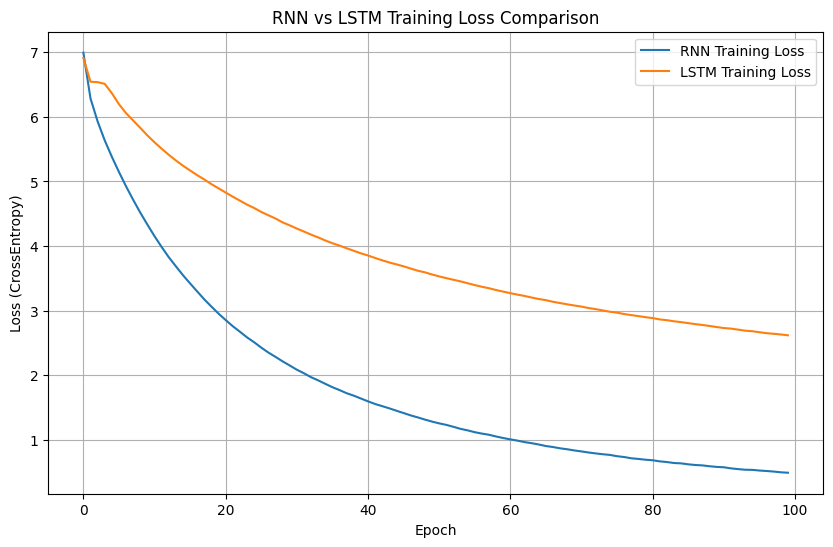

In [93]:
# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(train_loss_rnn, label='RNN Training Loss')
plt.plot(train_loss_lstm, label='LSTM Training Loss')
plt.title('RNN vs LSTM Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True)
plt.show()

In [94]:
print("\n" + "="*50)
print(f"GENERATION TESTS (Seed: '{SEED_TEXT}')")
print("="*50)

# 1. RNN Greedy Decoding
rnn_greedy_output = predict_rnn_argmax(dataset, rnn_model, SEED_TEXT, next_words=40)
print("\n1. RNN (Greedy - Argmax)")
print(" ".join(rnn_greedy_output))

# 2. RNN Sampling Decoding
rnn_sampling_output = predict_rnn_softmax(dataset, rnn_model, SEED_TEXT, next_words=40)
print("\n2. RNN (Sampling - Softmax)")
print(" ".join(rnn_sampling_output))

# 3. LSTM Greedy Decoding
lstm_greedy_output = predict_lstm_argmax(dataset, lstm_model, SEED_TEXT, next_words=40)
print("\n3. LSTM (Greedy - Argmax)")
print(" ".join(lstm_greedy_output))

# 4. LSTM Sampling Decoding
lstm_sampling_output = predict_lstm_softmax(dataset, lstm_model, SEED_TEXT, next_words=40)
print("\n4. LSTM (Sampling - Softmax)")
print(" ".join(lstm_sampling_output))


GENERATION TESTS (Seed: 'i went to the bar and saw')

1. RNN (Greedy - Argmax)
i went to the bar and saw a cow say to the other clean something it why did the melon cross the road naked his because he couldn t find a date why did the buddhist refuse novocaine when he went to get a tooth pulled he

2. RNN (Sampling - Softmax)
i went to the bar and saw the man say to the baby name up what did the 0 say to the 8 it s three the same bach i thought it would be a front b memory tv cash what do you call an imaginary color

3. LSTM (Greedy - Argmax)
i went to the bar and saw a cow with no legs ground beef how do you call a cow with no legs ground beef how do you call a cow with no legs ground beef how do you call a cow with no legs ground beef

4. LSTM (Sampling - Softmax)
i went to the bar and saw a rye while they re normally around 90 degrees a pterodactyl use divorce even what do you call a boomerang earlier i work at a communist propaganda film from the other break pac man waka waka mile 

### Task 2 (2 points)

The goal of this task is to download a multi-label text classification dataset from the [Hugging Face Hub](https://huggingface.co/datasets) and load it.

a) Select the `Text Classification` tag on the left, multi-label-classificationas as well as the the "1K<n<10K" tag to find a relatively small dataset. (e.g., sem_eval_2018_task_1 >> subtask5.english)

b) Load your dataset using `load_dataset` and check (print) the last data point in the validation set.

**Hint:** If you don't have access to GPU, you can downsample the dataset.

In [ ]:
# Here comes your code

### Task 3 (3 points)

a) Write a function `tokenize_data(dataset)` that takes the loaded dataset as input and returns the encoded dataset for both text and labels.


**Hints:**

1. You should tokenize the text using the BERT tokenizer `bert-base-uncased`
2. You also need to provide labels to the model as numbers. For multi-label text classification, this is a matrix of shape (batch_size, num_labels). This should be a tensor of floats rather than integers.
3. You can apply the function `tokenize_data(dataset)` to the the dataset using `map()`. (You can check out the exercise!)
4. You should set the format of the data to PyTorch tensors using `encoded_dataset.set_format("torch")`. This will turn the training, validation and test sets into standard PyTorch.

b) Print the `keys()` of the the last data point in the validation set in the encoded dataset.

**Hint:** The output should be as follows:

`dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])`

In [ ]:
def tokenize_data(dataset):
    # here comes your code
    return(encoded_dataset)

### Task 4 (15 points)

Implement and compare two different approaches for text classification on a multilabel dataset. One approach will utilize BERT for tokenization and classification, while the other will use an alternative method such as (TF-IDF + SVM) or (BOW + LR).

a) **BERT Approach:**


``1.`` Define a text classification model that includes a pre-trained base ``(bert-base-uncased)`` using ``AutoModelForSequenceClassification``.

**Hints:**

       
- Create two dictionaries that map labels to integers and vice versa for the ``id2label`` and ``label2id`` parameters in  `.from_pretrained function` .
        
- Set the `problem_type` to "multi_label_classification" to ensure the appropriate loss function is used.
        
``2.`` Train the BERT-based model using HuggingFace's Trainer API.

**Hints:**
- Utilize `TrainingArguments` and `Trainer` classes.

- While training, compute metrics using a ``compute_metrics`` function that returns a dictionary with the desired metric values.

b) **Alternative Approach:**


``1.`` Choose an alternative approach for tokenization and classification. For example, use TF-IDF  or Bag of Words (BoW) for tokenization and a traditional classifier like SVM or logistic regression for classification. Or, if you're very cool, use an LLM to tokenize and classify with pure prompting!

**Hints:**

  - Use scikit-learn library for the implementations (or HuggingFace transformers/OpenAI API).

``2.`` Train the alternative approach (model) on the same dataset you used for the BERT approach.

__Hints:__

  - Use appropriate training and evaluation procedures for the chosen alternative approach.
  
``3.`` Evaluate the performance of both models on the validation set using the metrics Accuracy, F1-score, precision, recall.

c) **Discussion:**

 Discuss the strengths and weaknesses of each approach.

__Note:__ Feel free to explore variations and improvements for both approaches. Experiment with hyperparameters and preprocessing steps to enhance the models' performance.


In [ ]:
# Here comes your code for BERT Approach

In [ ]:
# Here comes your code for the alternative approach

#### Here comes your discussion